<a href="https://colab.research.google.com/github/Royst97/DSRP_Roy/blob/main/DSRP_2026_Royston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Stuff:

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv("/content/lendingclub_loans_export.csv")

Exploring the Data:

In [11]:
print(df.dtypes, "\n")
print(df.info())

emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint            object
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever    

In [10]:

print(df.shape, "\n")
print(df.columns)

(10000, 55) 

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Cleaning the Data:

In [13]:
loans_df = pd.read_csv("lendingclub_loans_export.csv")

#Change NA values to null
loans_df = loans_df.replace("NA", np.nan)

#Droped join annual income columns (>85% null rate for both)
loans_df.drop(columns = ["annual_income_joint", "verification_income_joint"], inplace = True)

#All loans were 2018, remove year from issue month
loans_df["issue_month"] = pd.to_datetime(loans_df["issue_month"], format="%b-%Y").dt.strftime

#Grade information included in subgrade
loans_df.drop(columns = ["grade"], inplace = True)

loans_df.to_csv("lendingclub_loans_clean.csv")

In [20]:
#Checking for duplicates
print(df.duplicated().sum(), "\n")
print(df.info())

0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  e

In [34]:
solo_income_df = df[df["annual_income_joint"].isna()]

In [51]:
solo_income_df[["delinq_2y", "loan_purpose"]].head()

,delinq_2y,loan_purpose
0,0,moving
1,0,debt_consolidation
2,0,other
3,0,debt_consolidation
5,1,other


Visuals

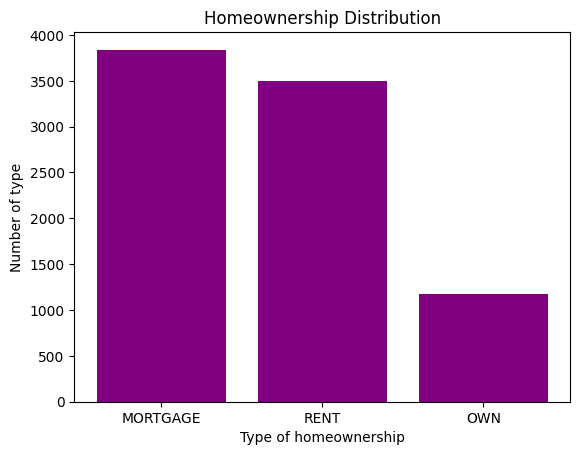

In [63]:
#I might want to do a question based on house ownership compared to something else so this visual is in preparation

x = solo_income_df["homeownership"].value_counts().index
y = solo_income_df["homeownership"].value_counts().values

plt.bar(x, y, color="purple")
plt.title("Homeownership Distribution")
plt.xlabel("Type of homeownership")
plt.ylabel("Number of type")

plt.show()

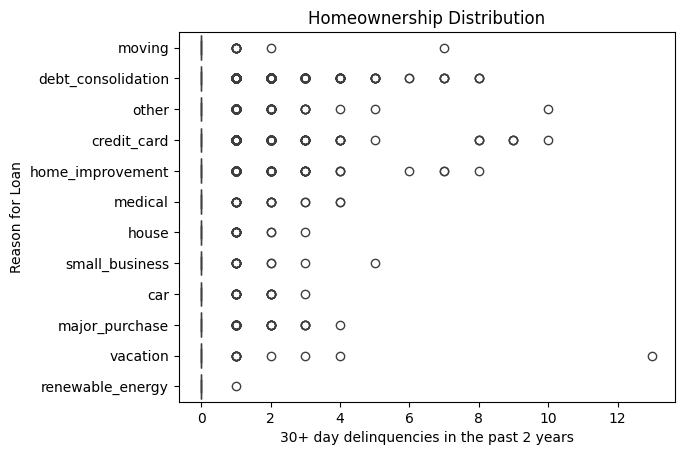

In [62]:
sns.boxplot(data=df, y="loan_purpose", x="delinq_2y")
plt.title("Homeownership Distribution")
plt.xlabel("30+ day delinquencies in the past 2 years")
plt.ylabel("Reason for Loan")

plt.show()